# Cardiovascular Disease Prediction — EDA & Preprocessing
### Team Phase 2 — Shared Notebook
**Dataset:** `cardiovascular_diseases_processed.csv`  
**Papers Referenced:**  
1. Baghdadi et al. (2023) — Journal of Big Data  
2. Ogunpola et al. (2024) — Diagnostics  
3. Tompra et al. (2024) — Algorithms


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif, RFE
from sklearn.ensemble import RandomForestClassifier
import warnings

## 1. Data Loading & First Look

In [ ]:
df = pd.read_csv('cardiovascular_diseases_processed.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (68783, 12)

First 5 rows:


,AGE,GENDER,HEIGHT,WEIGHT,AP_HIGH,AP_LOW,CHOLESTEROL,GLUCOSE,SMOKE,ALCOHOL,PHYSICAL_ACTIVITY,CARDIO_DISEASE
0,50,2,168,62,110,80,1,1,0,0,1,0
1,55,1,156,85,140,90,3,1,0,0,1,1
2,52,1,165,64,130,70,3,1,0,0,0,1
3,48,2,169,82,150,100,1,1,0,0,1,1
4,48,1,156,56,100,60,1,1,0,0,0,0


In [ ]:
print("Column data types:\n")
print(df.dtypes)
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024:.1f} KB")

Column data types:

AGE                  int64
GENDER               int64
HEIGHT               int64
WEIGHT               int64
AP_HIGH              int64
AP_LOW               int64
CHOLESTEROL          int64
GLUCOSE              int64
SMOKE                int64
ALCOHOL              int64
PHYSICAL_ACTIVITY    int64
CARDIO_DISEASE       int64
dtype: object

Memory usage: 6448.5 KB


## 2. Exploratory Data Analysis (EDA)
### 2.1 Statistical Summary

In [ ]:
df.describe()

,AGE,GENDER,HEIGHT,WEIGHT,AP_HIGH,AP_LOW,CHOLESTEROL,GLUCOSE,SMOKE,ALCOHOL,PHYSICAL_ACTIVITY,CARDIO_DISEASE
count,68783.000000,68783.000000,68783.000000,68783.000000,68783.000000,68783.000000,68783.000000,68783.000000,68783.000000,68783.000000,68783.000000,68783.000000
mean,53.326781,1.348749,164.361252,74.121934,126.614585,81.381591,1.364727,1.225986,0.088001,0.053632,0.803367,0.494904
std,6.768163,0.476578,8.184850,14.331392,16.763763,9.676679,0.678976,0.571961,0.283299,0.225293,0.397455,0.499978
min,30.000000,1.000000,55.000000,11.000000,60.000000,40.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,58.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,65.000000,2.000000,250.000000,200.000000,240.000000,190.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


### 2.2 Missing Values Analysis

In [ ]:
print(f"Missing values: {df.isnull().sum().sum()}")

Missing values: 0


### 2.3 Target Variable Distribution

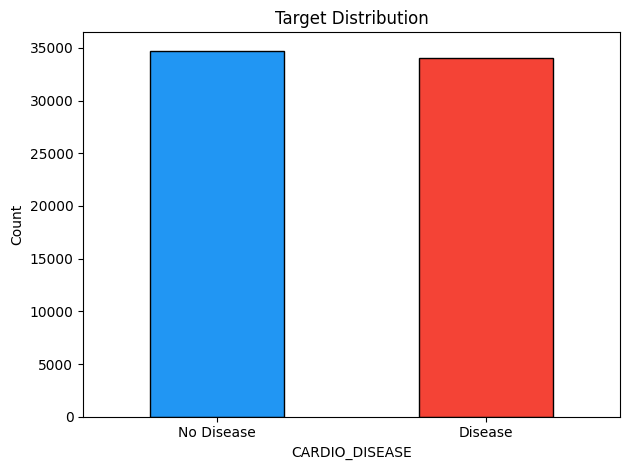

CARDIO_DISEASE
0    34742
1    34041
Name: count, dtype: int64


In [ ]:
counts = df['CARDIO_DISEASE'].value_counts()
counts.plot(kind='bar', color=['#2196F3', '#F44336'], edgecolor='black')
plt.xticks([0, 1], ['No Disease', 'Disease'], rotation=0)
plt.title('Target Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(counts)

### 2.4 Feature Distributions

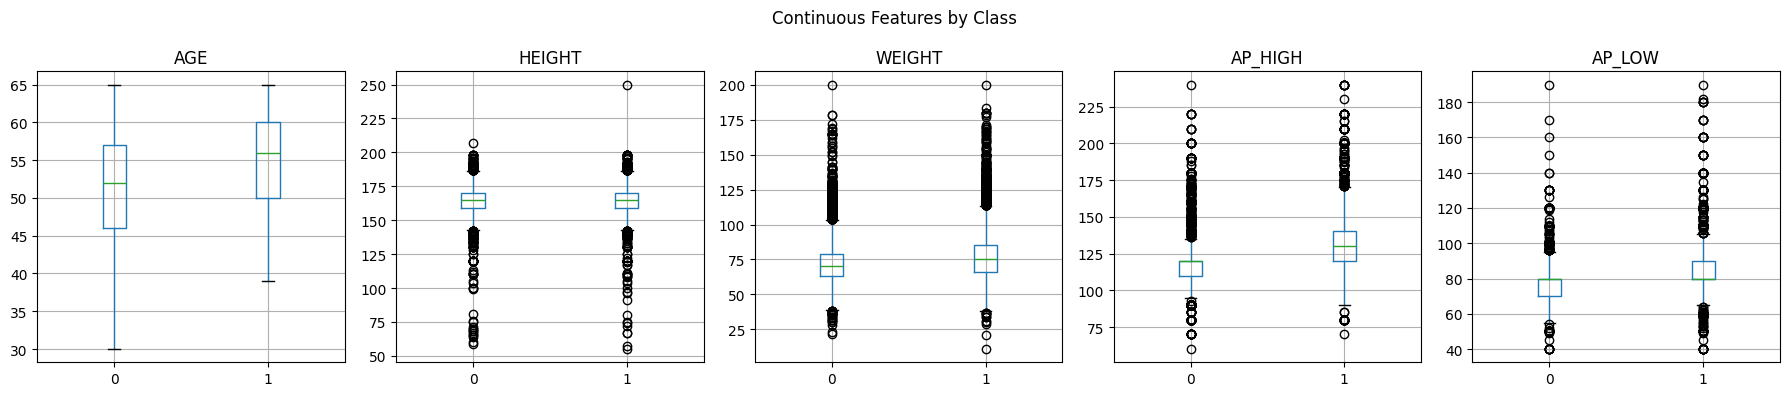

In [ ]:
continuous_cols = ['AGE', 'HEIGHT', 'WEIGHT', 'AP_HIGH', 'AP_LOW']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i, col in enumerate(continuous_cols):
    df.boxplot(column=col, by='CARDIO_DISEASE', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.suptitle('Continuous Features by Class')
plt.tight_layout()
plt.show()

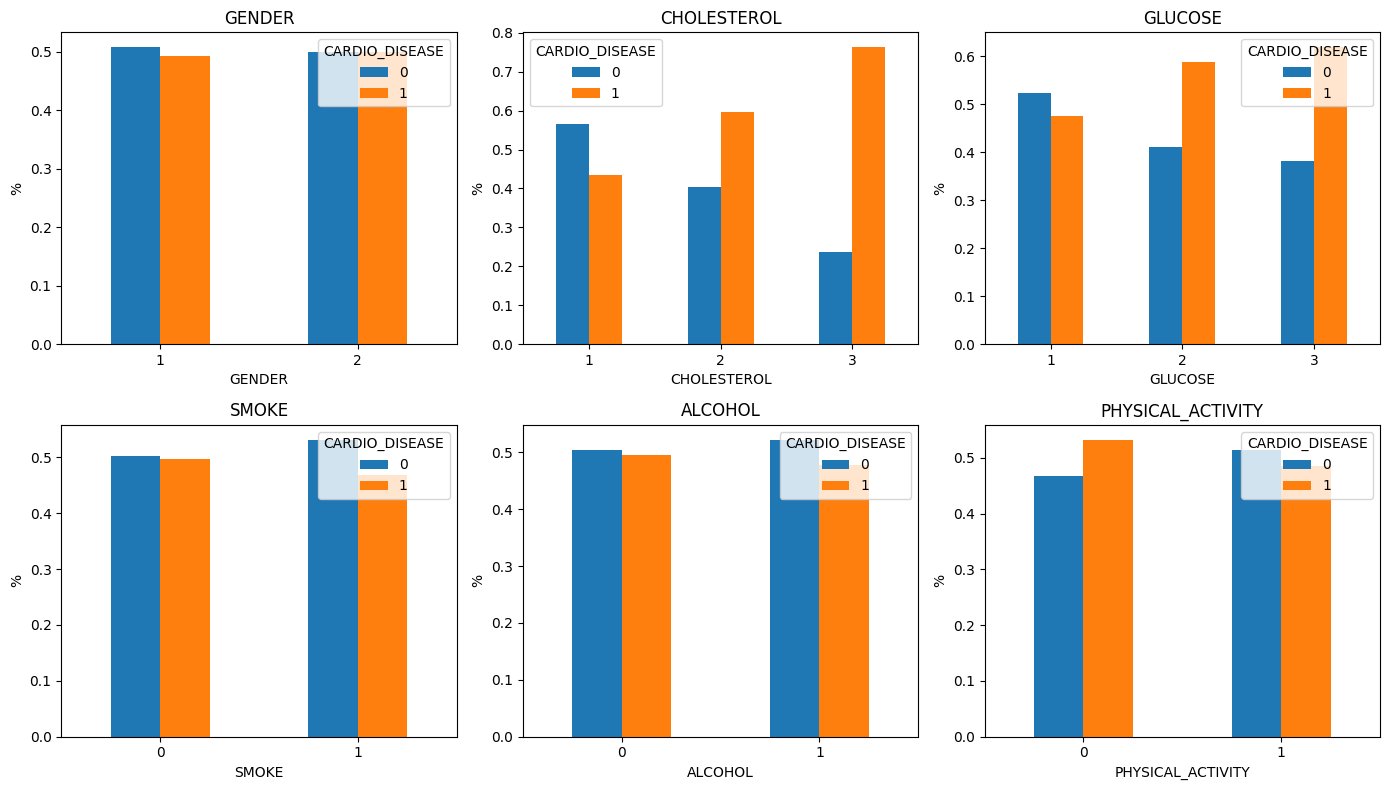

In [ ]:
cat_cols = ['GENDER', 'CHOLESTEROL', 'GLUCOSE', 'SMOKE', 'ALCOHOL', 'PHYSICAL_ACTIVITY']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flatten(), cat_cols):
    pd.crosstab(df[col], df['CARDIO_DISEASE'], normalize='index').plot(kind='bar', ax=ax, rot=0)
    ax.set_title(col)
    ax.set_ylabel('%')

plt.tight_layout()
plt.show()

### 2.5 Correlation Analysis

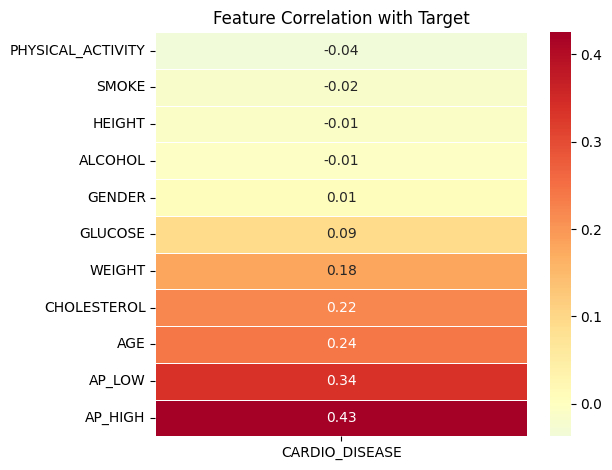

In [ ]:
corr = df.corr()[['CARDIO_DISEASE']].drop('CARDIO_DISEASE').sort_values('CARDIO_DISEASE')

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0, linewidths=0.5)
plt.title('Feature Correlation with Target')
plt.tight_layout()
plt.show()


### 2.6 Outlier Detection

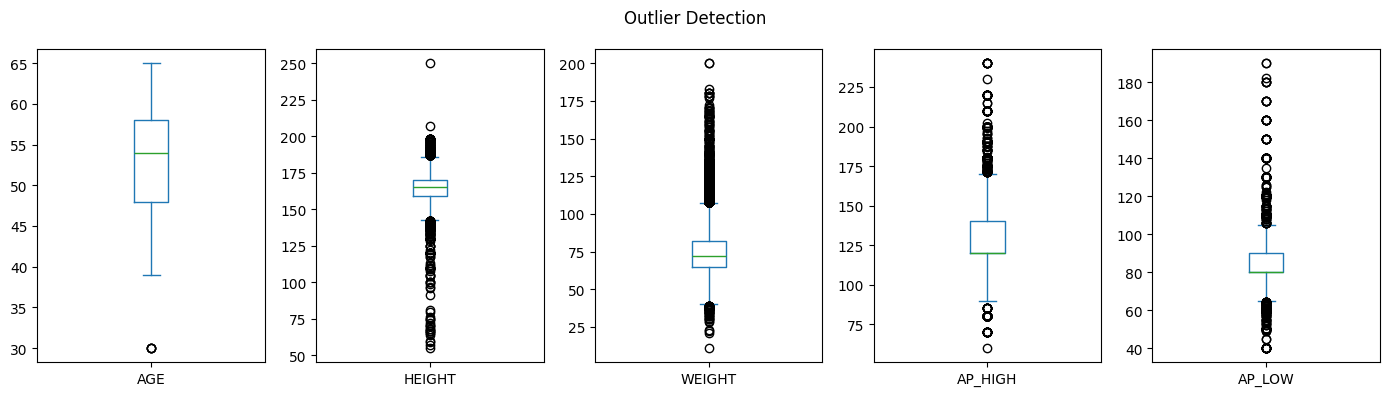

,Outlier Count
AGE,4
HEIGHT,507
WEIGHT,1748
AP_HIGH,1068
AP_LOW,3599


In [ ]:
continuous_cols = ['AGE', 'HEIGHT', 'WEIGHT', 'AP_HIGH', 'AP_LOW']

df[continuous_cols].plot(kind='box', figsize=(14, 4), subplots=True, layout=(1,5))
plt.suptitle('Outlier Detection')
plt.tight_layout()
plt.show()
def count_outliers(col):
    Q1, Q3 = col.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    return ((col < Q1 - 1.5*IQR) | (col > Q3 + 1.5*IQR)).sum()

df[continuous_cols].apply(count_outliers).rename('Outlier Count')

### 2.7 Age & Blood Pressure Risk Analysis

/tmp/ipykernel_37074/3516829465.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AGE_GROUP')['CARDIO_DISEASE'].mean().mul(100).plot(kind='bar', rot=0)


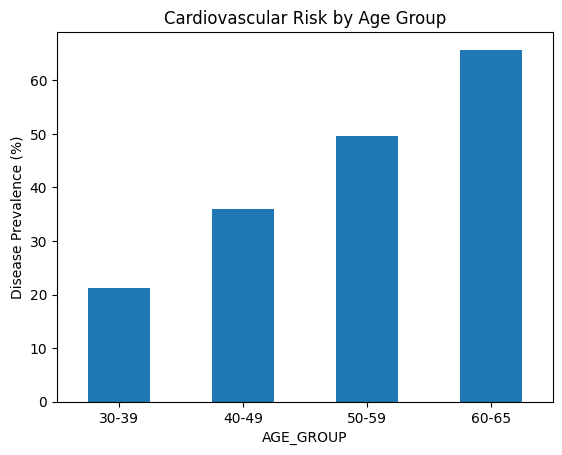

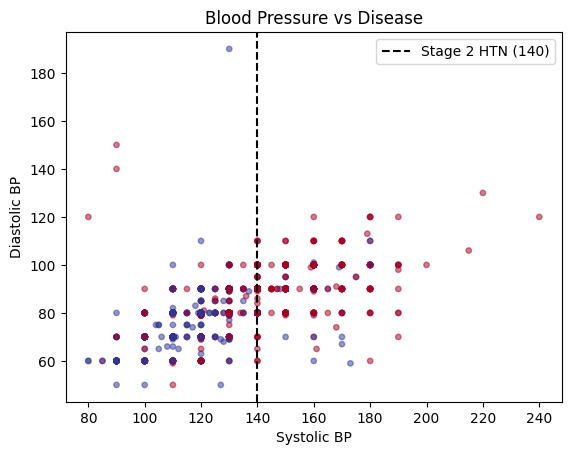

In [ ]:
# Age risk
df['AGE_GROUP'] = pd.cut(df['AGE'], bins=[29, 39, 49, 59, 66], labels=['30-39', '40-49', '50-59', '60-65'])
df.groupby('AGE_GROUP')['CARDIO_DISEASE'].mean().mul(100).plot(kind='bar', rot=0)
plt.title('Cardiovascular Risk by Age Group')
plt.ylabel('Disease Prevalence (%)')
plt.show()

# Blood pressure scatter
sample = df.sample(3000, random_state=42)
plt.scatter(sample['AP_HIGH'], sample['AP_LOW'], c=sample['CARDIO_DISEASE'], cmap='RdYlBu_r', alpha=0.5, s=15)
plt.axvline(x=140, color='black', linestyle='--', label='Stage 2 HTN (140)')
plt.xlabel('Systolic BP')
plt.ylabel('Diastolic BP')
plt.title('Blood Pressure vs Disease')
plt.legend()
plt.show()

## 3. Data Preprocessing
### 3.1 Outlier Handling — Capping (Winsorization)

In [ ]:
df_clean = df.drop(columns=['AGE_GROUP'], errors='ignore').copy()

continuous_cols = ['AGE', 'HEIGHT', 'WEIGHT', 'AP_HIGH', 'AP_LOW']
for col in continuous_cols:
    df_clean[col] = df_clean[col].clip(df_clean[col].quantile(0.01), df_clean[col].quantile(0.99))

print(f"Done. Shape: {df_clean.shape}")

Done. Shape: (68783, 12)


### 3.2 Feature Engineering

In [ ]:
df_clean['BMI']            = df_clean['WEIGHT'] / (df_clean['HEIGHT'] / 100) ** 2
df_clean['PULSE_PRESSURE'] = df_clean['AP_HIGH'] - df_clean['AP_LOW']
df_clean['MAP']            = (df_clean['AP_HIGH'] + 2 * df_clean['AP_LOW']) / 3
df_clean['HYPERTENSION']   = ((df_clean['AP_HIGH'] >= 140) | (df_clean['AP_LOW'] >= 90)).astype(int)
df_clean['OBESE']          = (df_clean['BMI'] >= 30).astype(int)

print(f"Features: {df_clean.shape[1]} | Rows: {df_clean.shape[0]}")

Features: 17 | Rows: 68783


### 3.3 Train/Test Split & Scaling

In [ ]:
X = df_clean.drop(columns=['CARDIO_DISEASE'])
y = df_clean['CARDIO_DISEASE']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)



In [ ]:
X_train.shape

(55026, 16)

## 4. Feature Selection
### 4.1 Mutual Information

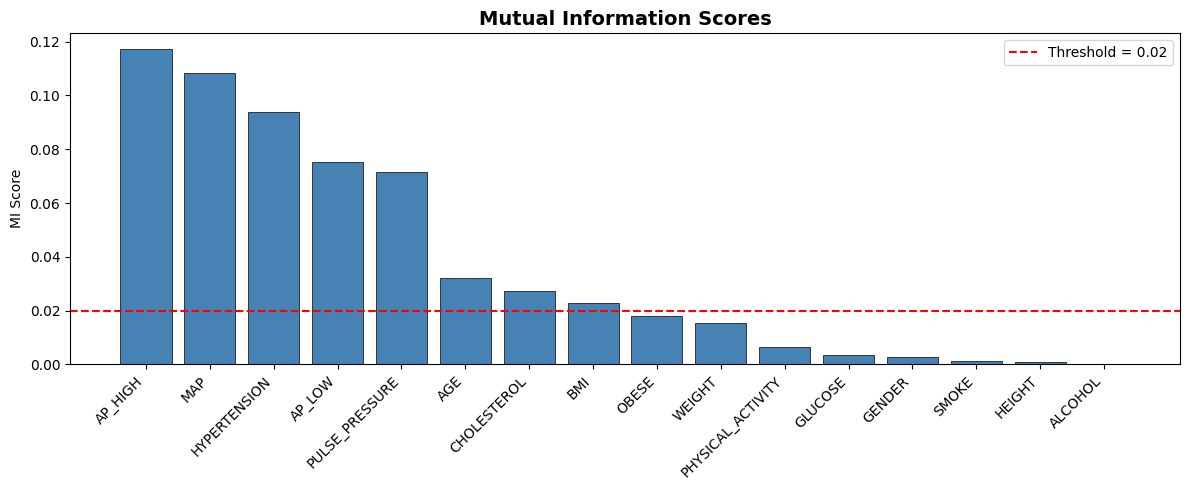

Feature ranking by Mutual Information:
AP_HIGH              0.117249
MAP                  0.108303
HYPERTENSION         0.094039
AP_LOW               0.075162
PULSE_PRESSURE       0.071385
AGE                  0.032194
CHOLESTEROL          0.027163
BMI                  0.022648
OBESE                0.018035
WEIGHT               0.015263
PHYSICAL_ACTIVITY    0.006596
GLUCOSE              0.003378
GENDER               0.002593
SMOKE                0.001341
HEIGHT               0.001005
ALCOHOL              0.000000
dtype: float64


In [ ]:
mi_scores = mutual_info_classif(X_train_scaled, y_train, random_state=42)
mi_df = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 5))
bars = plt.bar(mi_df.index, mi_df.values, color='steelblue', edgecolor='black', linewidth=0.5)
plt.xticks(rotation=45, ha='right')
plt.title('Mutual Information Scores', fontsize=14, fontweight='bold')
plt.ylabel('MI Score')
plt.axhline(y=0.02, color='red', linestyle='--', label='Threshold = 0.02')
plt.legend()
plt.tight_layout()
plt.show()

print("Feature ranking by Mutual Information:")
print(mi_df)

Accuracy:  0.7276
ROC-AUC:   0.7958

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.71      0.77      0.74      6949
     Disease       0.74      0.68      0.71      6808

    accuracy                           0.73     13757
   macro avg       0.73      0.73      0.73     13757
weighted avg       0.73      0.73      0.73     13757



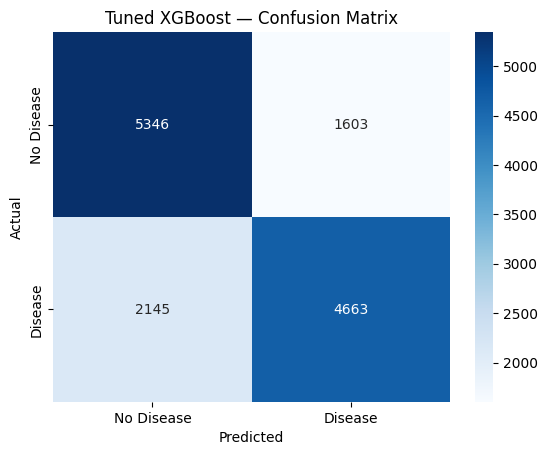

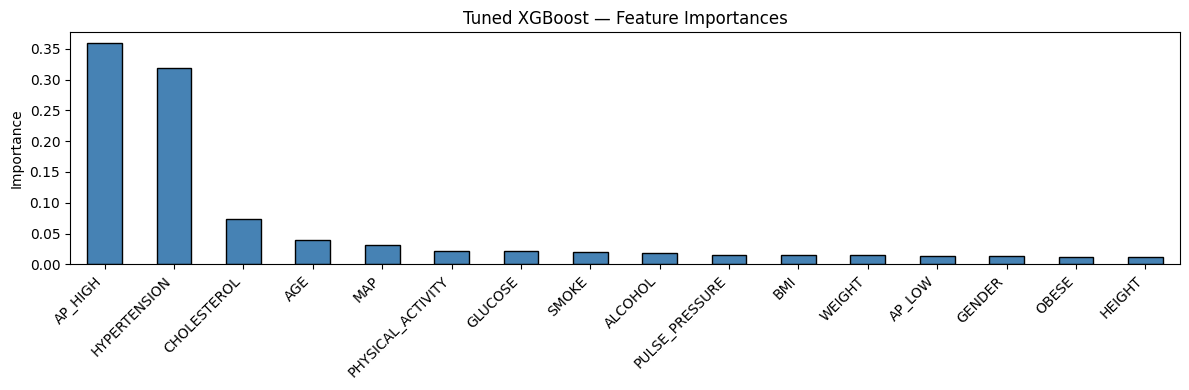

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.05,
    reg_lambda=1.5,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train_scaled, y_train)

y_pred = xgb.predict(X_test_scaled)
y_prob = xgb.predict_proba(X_test_scaled)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.title('Tuned XGBoost — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

fi = pd.Series(xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)
fi.plot(kind='bar', figsize=(12, 4), color='steelblue', edgecolor='black')
plt.title('Tuned XGBoost — Feature Importances')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Accuracy:  0.7297
ROC-AUC:   0.7973

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.72      0.77      0.74      6949
     Disease       0.75      0.69      0.72      6808

    accuracy                           0.73     13757
   macro avg       0.73      0.73      0.73     13757
weighted avg       0.73      0.73      0.73     13757



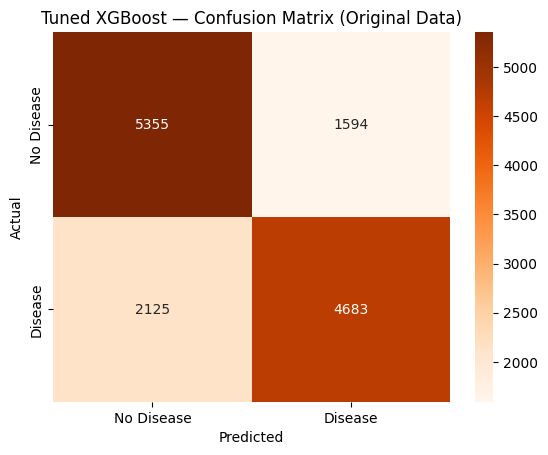


--- Accuracy Comparison ---
Engineered data accuracy:  0.7276
Original data accuracy:    0.7297


In [ ]:
X_raw = df.drop(columns=['CARDIO_DISEASE', 'AGE_GROUP'], errors='ignore')
y_raw = df['CARDIO_DISEASE']

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

scaler_raw = StandardScaler()
X_train_raw_scaled = pd.DataFrame(scaler_raw.fit_transform(X_train_raw), columns=X_train_raw.columns)
X_test_raw_scaled  = pd.DataFrame(scaler_raw.transform(X_test_raw),  columns=X_test_raw.columns)

xgb_raw = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.05,
    reg_lambda=1.5,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb_raw.fit(X_train_raw_scaled, y_train_raw)

y_pred_raw = xgb_raw.predict(X_test_raw_scaled)
y_prob_raw = xgb_raw.predict_proba(X_test_raw_scaled)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test_raw, y_pred_raw):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test_raw, y_prob_raw):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_raw, y_pred_raw, target_names=['No Disease', 'Disease']))

sns.heatmap(confusion_matrix(y_test_raw, y_pred_raw), annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.title('Tuned XGBoost — Confusion Matrix (Original Data)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print("\n--- Accuracy Comparison ---")
print(f"Engineered data accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Original data accuracy:    {accuracy_score(y_test_raw, y_pred_raw):.4f}")


## 5. Explainability — SHAP Analysis
SHAP (SHapley Additive exPlanations) provides a unified framework to explain the output of any machine learning model. It assigns each feature a Shapley value — the average marginal contribution of that feature across all possible feature subsets. This gives us both **global** insights (which features matter most overall) and **local** insights (why the model made a specific prediction for an individual patient).

In [ ]:
pip install shap

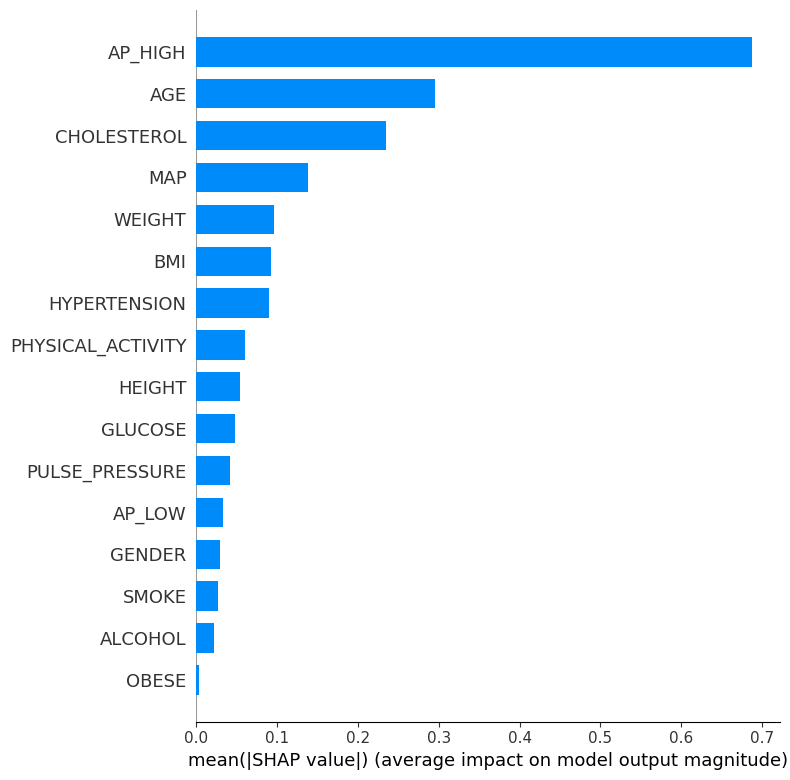

In [ ]:
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test_scaled)

shap.summary_plot(shap_values, X_test_scaled, plot_type="bar")


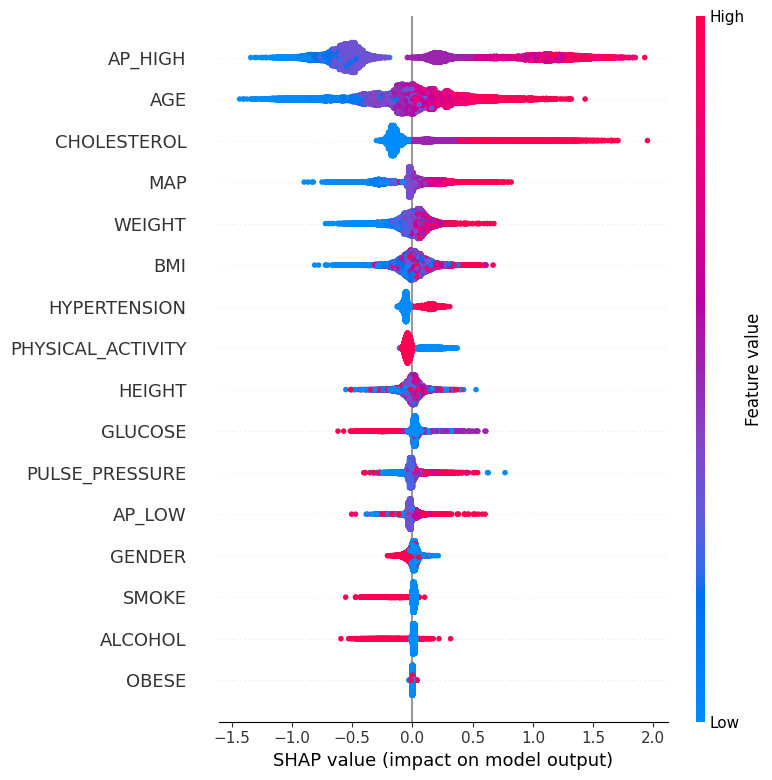

In [ ]:

shap.summary_plot(shap_values, X_test_scaled)

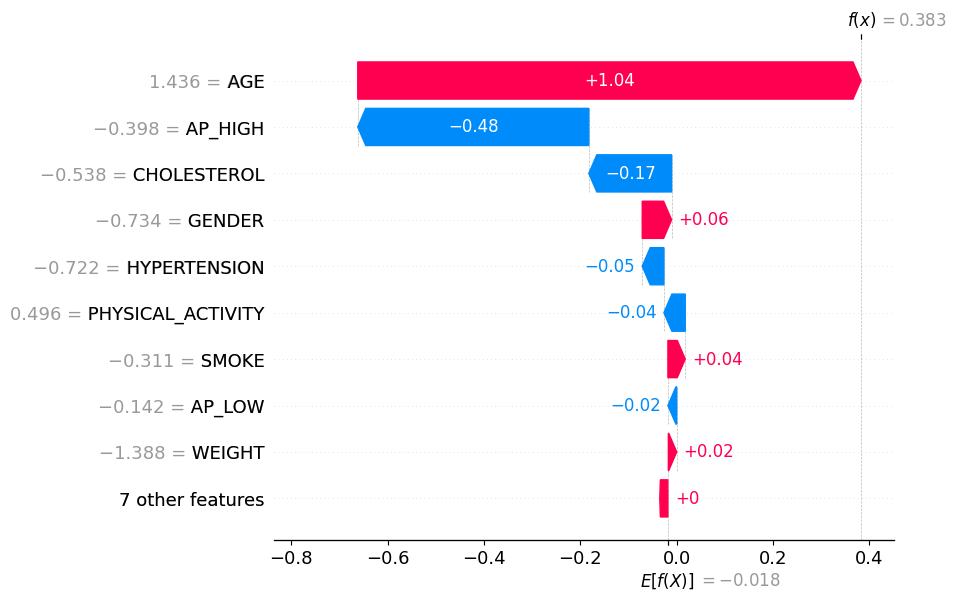

In [ ]:
shap.plots.waterfall(shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=X_test_scaled.iloc[0],
    feature_names=X_test_scaled.columns.tolist()
))